# Power law? Or just a guideline?

Part two. See ctokens.ipynb for part one.

In [1]:
# Install empiricaldist if we don't already have it

try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [2]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download(
    "https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/notebooks/utils.py"
)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate
from utils import empirical_error_bounds
from utils import plot_error_bounds

In [4]:
# Make the figures smaller to save some screen real estate
plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

## Data

First, let's download the data and supporting scripts from Hatton's site.

In [5]:
download(
    "http://www.leshatton.org/Documents/HattonWarr_SharedProps_Apr2025.zip"
)

Here are the files in the zip archive.

In [6]:
import zipfile

zip_path = "HattonWarr_SharedProps_Apr2025.zip"

with zipfile.ZipFile(zip_path, 'r') as zf:
    file_list = zf.namelist()

Here's the script that generates the PMF of token lengths.

In [7]:
target_file = "3-fig4AB.sh"

with zipfile.ZipFile(zip_path, 'r') as zf:
    with zf.open(target_file) as f:
        # Read as bytes and decode to string
        contents = f.read().decode("utf-8")

Now we can put the results in a DataFrame.

In [8]:
target_file = "24-06_trembl_pdf.dat"

with zipfile.ZipFile(zip_path, "r") as zf:
    with zf.open(target_file) as f:
        df = pd.read_csv(
            f,
            comment="#",        # skip header lines starting with '#'
            delim_whitespace=True,
            names=["value", "freq"]
        )

Before we do anything else, let's compute the log of the token lengths.

In [9]:
df['mag'] = np.log10(df['value'])
df.head()

,value,freq,mag
0,7,130,0.845098
1,8,10885,0.903090
2,9,16432,0.954243
3,10,17303,1.000000
4,11,14607,1.041393


And the total number of values.

In [10]:
count = df['freq'].sum()
count

251254507

Here's a `Pmf` of the magnitudes.

In [11]:
from empiricaldist import Pmf

pmf = Pmf(df['freq'].values, df['mag'])
pmf.normalize()

251254507

The following function computes the tail distribution (fraction of values >= x for all x).

In [12]:
from empiricaldist import Pmf, Surv


def make_surv(pmf):
    """Make a non-standard survival function, P(X>=x)"""
    surv = pmf.make_surv() + pmf

    # correct for numerical error
    surv.iloc[0] = 1
    return Surv(surv)

Here's what it looks like.

In [13]:
surv = make_surv(pmf)

In [14]:
xlabel = "Protein length (log10)"
ylabel = "Prob >= $x$"

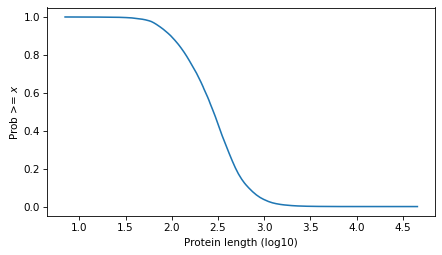

In [15]:
surv.plot()

decorate(xlabel=xlabel, ylabel=ylabel)

And here it is on a log scale.

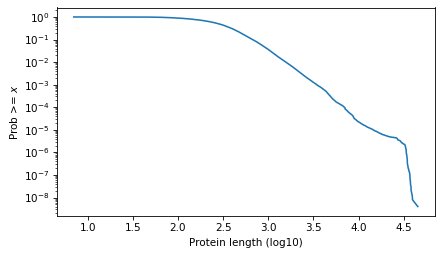

In [16]:
surv.plot()

decorate(xlabel=xlabel, ylabel=ylabel, yscale='log')
plt.savefig("proteins1.png", dpi=300)

## Fit a Power Law

Select the part of the curve that looks like a straight line.

In [17]:
low, high = -1, -5
ps = np.logspace(low, high, 20)
qs = surv.inverse(ps)

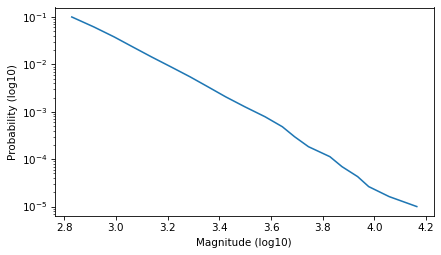

In [18]:
plt.plot(qs, ps)
decorate(xlabel='Magnitude (log10)', ylabel='Probability (log10)', yscale='log')

And fit a line to it.

In [19]:
from scipy.stats import linregress

log_ps = np.log10(ps)
result = linregress(qs, log_ps)
result

LinregressResult(slope=-3.0982449194692387, intercept=7.8772243002229825, rvalue=-0.9986259969715762, pvalue=1.6492457998656753e-24, stderr=0.03832094735310883, intercept_stderr=0.13536901050675956)

Extend the line to the full domain.

In [20]:
log_ps_ext = result.intercept + result.slope * surv.qs
ps_ext = np.power(10, log_ps_ext)

surv_power_law = Surv(ps_ext, surv.qs)

Here's what it looks like on a log-log scale.

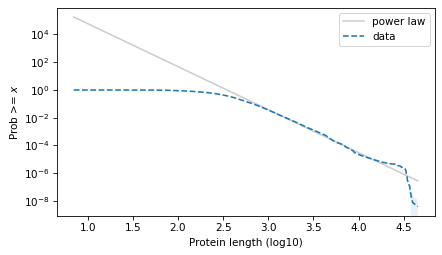

In [21]:
surv_power_law.plot(color='gray', alpha=0.4, label='power law')

plot_error_bounds(surv, count, color="C0")
surv.plot(ls='--', label="data")

decorate(xlabel=xlabel, ylabel=ylabel, yscale='log')
plt.savefig("proteins2.png", dpi=300)

And on a linear y scale.

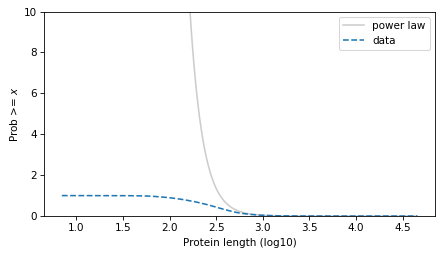

In [22]:
surv_power_law.plot(color='gray', alpha=0.4, label='power law')
surv.plot(ls='--', label='data')

decorate(xlabel=xlabel, ylabel=ylabel, ylim=[0, 10])
plt.savefig("proteins3.png", dpi=300)

Compute residuals as differences in log survival function.

In [23]:
resid_power_law = np.log10(surv_power_law.ps) - np.log10(surv.ps)

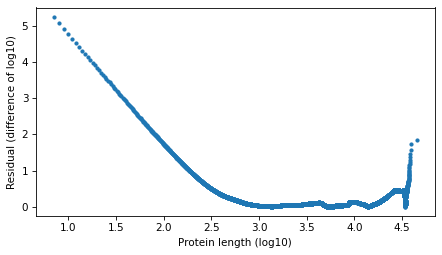

In [24]:
plt.plot(surv.qs, np.abs(resid_power_law), '.')

decorate(xlabel=xlabel, ylabel='Residual (difference of log10)')

## Fit a Student t

First we'll find the `df` parameter that best matches the tail, then the `mu` and `sigma` parameters that best match the percentiles.

In [25]:
from scipy.stats import t as t_dist


def truncated_t_sf(qs, df, mu, sigma):
    ps = t_dist.sf(qs, df, mu, sigma)
    surv_model = Surv(ps / ps[0], qs)
    return surv_model

In [26]:
from scipy.optimize import least_squares


def fit_truncated_t(df, surv):
    """Given df, find the best values of mu and sigma."""
    low, high = surv.qs.min(), surv.qs.max()
    qs_model = np.linspace(low, high, 1000)

    # match 20 percentiles from 1st to 99th
    ps = np.linspace(0.01, 0.99, 20)
    qs = surv.inverse(ps)

    def error_func_t(params, df, surv):
        mu, sigma = params
        surv_model = truncated_t_sf(qs_model, df, mu, sigma)

        error = surv(qs) - surv_model(qs)
        return error

    params = surv.mean(), surv.std()
    res = least_squares(error_func_t, x0=params, args=(df, surv), xtol=1e-3)
    assert res.success
    return res.x

In [27]:
from scipy.optimize import minimize


def minimize_df(df0, surv, bounds=[(1, 1e6)], ps=None):
    low, high = surv.qs.min(), surv.qs.max()
    qs_model = np.linspace(low, high * 1.0, 2000)

    if ps is None:
        # fit the tail over these orders of magnitude
        ps = np.logspace(-1, -5, 20)

    qs = surv.inverse(ps)

    def error_func_tail(params):
        (df,) = params
        mu, sigma = fit_truncated_t(df, surv)
        surv_model = truncated_t_sf(qs_model, df, mu, sigma)

        errors = np.log10(surv(qs)) - np.log10(surv_model(qs))
        return np.sum(errors**2)

    params = (df0,)
    res = minimize(error_func_tail, x0=params, bounds=bounds, tol=1e-3, method="Powell")
    assert res.success
    return res.x

Search for the value of df that best matches the tail behavior.

In [28]:
df = minimize_df(5, surv, [(1, 100)])
df

array([22.58669028])

Given that value of `df`, find `mu` and `sigma` to best match percentiles.

In [29]:
mu, sigma = fit_truncated_t(df, surv)
df, mu, sigma

(array([22.58669028]), 2.4369128138364107, 0.3145746370844557)

Evaluate the model over the range of the data.

In [30]:
surv_model = truncated_t_sf(surv.qs, df, mu, sigma)

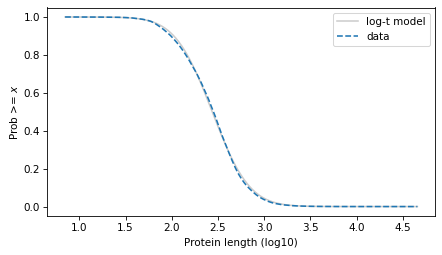

In [31]:
surv_model.plot(color="gray", alpha=0.4, label="log-t model")
surv.plot(ls="--", label="data")

decorate(xlabel=xlabel, ylabel=ylabel)
plt.savefig("proteins4.png", dpi=300)

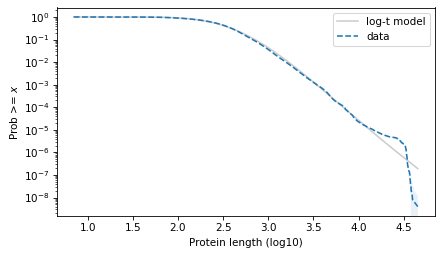

In [32]:
surv_model.plot(color="gray", alpha=0.4, label="log-t model")
surv.plot(ls="--", label="data")

plot_error_bounds(surv, count, color="C0")

decorate(xlabel=xlabel, ylabel=ylabel, yscale="log")
plt.savefig("proteins5.png", dpi=300)

In [33]:
resid_t = np.log10(surv_model.ps) - np.log10(surv.ps)

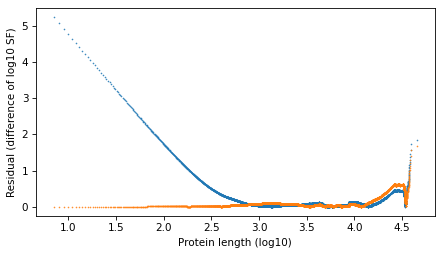

In [34]:
plt.plot(surv.qs, np.abs(resid_power_law), '.', ms=1)
plt.plot(surv.qs, np.abs(resid_t), '.', ms=1)

decorate(xlabel=xlabel, ylabel='Residual (difference of log10 SF)')
plt.savefig("proteins6.png", dpi=300)

The results with the protein lengths are similar to the results with the function lengths.

The power law model is a little better in the extreme tail.
They are about the same in the middle.
And the t model is much better to the left of the median.

Allen Downey
[MIT License](https://mit-license.org/)